<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
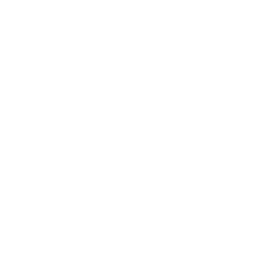
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolation af indskrivning fra kvartal til måned</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisk / Klinisk drift &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Sammenfatning for ledelsen

Dette gennemarbejdede eksempel konverterer **kvartalsvise** indskrivningstal fra et klinisk forsøg til **månedlige** estimater med PROC EXPAND, så ressourceplanlægning på site-niveau kan køre i en månedlig kadence. Det syntetiske forsøg spænder over **fire investigatorsites** i to regioner (Nordamerika og Europa) over **otte kvartaler** (Q1 2024 til og med Q4 2025), hvilket giver **32 kvartalsvise observationer**. PROC EXPAND interpolerer hvert sites serie fra kvartalsvis til månedlig frekvens og forvandler de 32 kvartalsvise rækker til **96 månedlige rækker**. Indskrevne tal interpoleres med `METHOD=JOIN` (stykkevis lineær, hvilket holder hvert estimat ikke-negativt), og det løbende kumulative interpoleres med `METHOD=SPLINE`. Den interpolerede månedlige serie passerer nøjagtigt gennem de oprindelige kvartalsvise ankerpunkter, så konverteringen tilføjer detaljer inden for kvartalet uden at ændre de kvartalstal, studiet allerede har rapporteret.


## Datakilder

| Kilde | Beskrivelse | Antal poster |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Kvartalsvise indskrivningstal pr. site (4 sites x 8 kvartaler) | 32 |
| WORK.SITE_MASTER | Site-reference: navn, land, region, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Genererer kvartalsvise indskrivningstal pr. site.
   4 sites x 8 kvartaler (Q1-2024 til Q4-2025) = 32 rækker.
   En optrapningskurve (langsom start, plateau) plus et mildt
   sæsonled og lidt støj giver en realistisk indskrivningsform.
   -------------------------------------------------------- */
data work.enrollment_qtr;
    CALL streaminit(42);
    format quarter_date yyq7.;
    TABEL capacity[4] _temporary_ (12 9 14 8);
    GØR site_num = 1 TIL 4;
        site_id = cat('SITE-', SKRIV_V(site_num, z3.));
        region  = ifc(site_num <= 2, 'NORDAMERIKA', 'EUROPA');
        base_rate = capacity[site_num];
        GØR qtr_seq = 0 TIL 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            UDDATA;
        SLUT;
    SLUT;
    FJERN site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
KØR;

/* Løbende kumuleret indskrivning inden for hvert site */
PROCEDURE SORTER data=work.enrollment_qtr;
    EFTER site_id quarter_date;
KØR;

data work.enrollment_qtr;
    SÆT work.enrollment_qtr;
    EFTER site_id;
    BEHOLD_VÆRDI cum_enrolled 0;
    HVIS first.site_id SÅ cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    FJERN cum_enrolled;
KØR;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site-referencetabel (4 sites, 2 regioner)
   -------------------------------------------------------- */
data work.site_master;
    LÆNGDE site_id $8 site_name $40 region $20 country $20 pi_name $30;
    TABEL names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    TABEL countries[4] $20 _temporary_ ('USA' 'Storbritannien' 'Tyskland' 'Tyskland');
    GØR i = 1 TIL 4;
        site_id   = cat('SITE-', SKRIV_V(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'NORDAMERIKA', 'EUROPA');
        pi_name   = cat('Dr. Investigator-', SKRIV_V(i, z2.));
        UDDATA;
    SLUT;
    FJERN i;
KØR;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline for kvartalsvis indskrivning efter region
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.enrollment_qtr n sum mean MAX;
    KLASSE region;
    VARIABEL enrolled_count cumulative_enrolled;
    MÆRKAT region='Region' enrolled_count='Indskrevne (antal)'
          cumulative_enrolled='Kumuleret indskrivning';
    UDDATA out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
KØR;

PROCEDURE UDSKRIV data=work.qtr_baseline noobs;
    MÆRKAT region='Region' total_enrolled='Indskrevne i alt'
          avg_per_quarter='Gnsn. pr. kvartal' max_cumulative='Maks. kumuleret';
    TITEL 'Kvartalsvis indskrivningsbaseline efter region';
KØR;


                                                  The MEANS Procedure

                                 Analysis Variable : enrolled_count Indskrevne (antal)

        Region               N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------
        EUROPA                  16    120.0000000      7.5000000     13.0000000
        NORDAMERIKA             16    115.0000000      7.1875000     10.0000000
        -----------------------------------------------------------------------

                             Analysis Variable : cumulative_enrolled Kumuleret indskrivning

        Region               N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------
        EUROPA                  16    493.0000000     30.8125000     81.0000000
        NORDAMERIKA             16    474.0000000     29.6250000     63.0000000
        -------------------


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Baselinen bekræfter et balanceret design: hver region bidrager med **16 kvartalsvise observationer**. Nordamerika indskriver i alt **115 forsøgspersoner** (gennemsnit **7.19** pr. site-kvartal) og Europa **120** (gennemsnit **7.50**). Det største kumulative tal nået over de otte kvartaler er **81** forsøgspersoner (Europas SITE-003) mod **63** i Nordamerika.


---

                                     Kvartalsvis indskrivningsbaseline efter region                                     




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


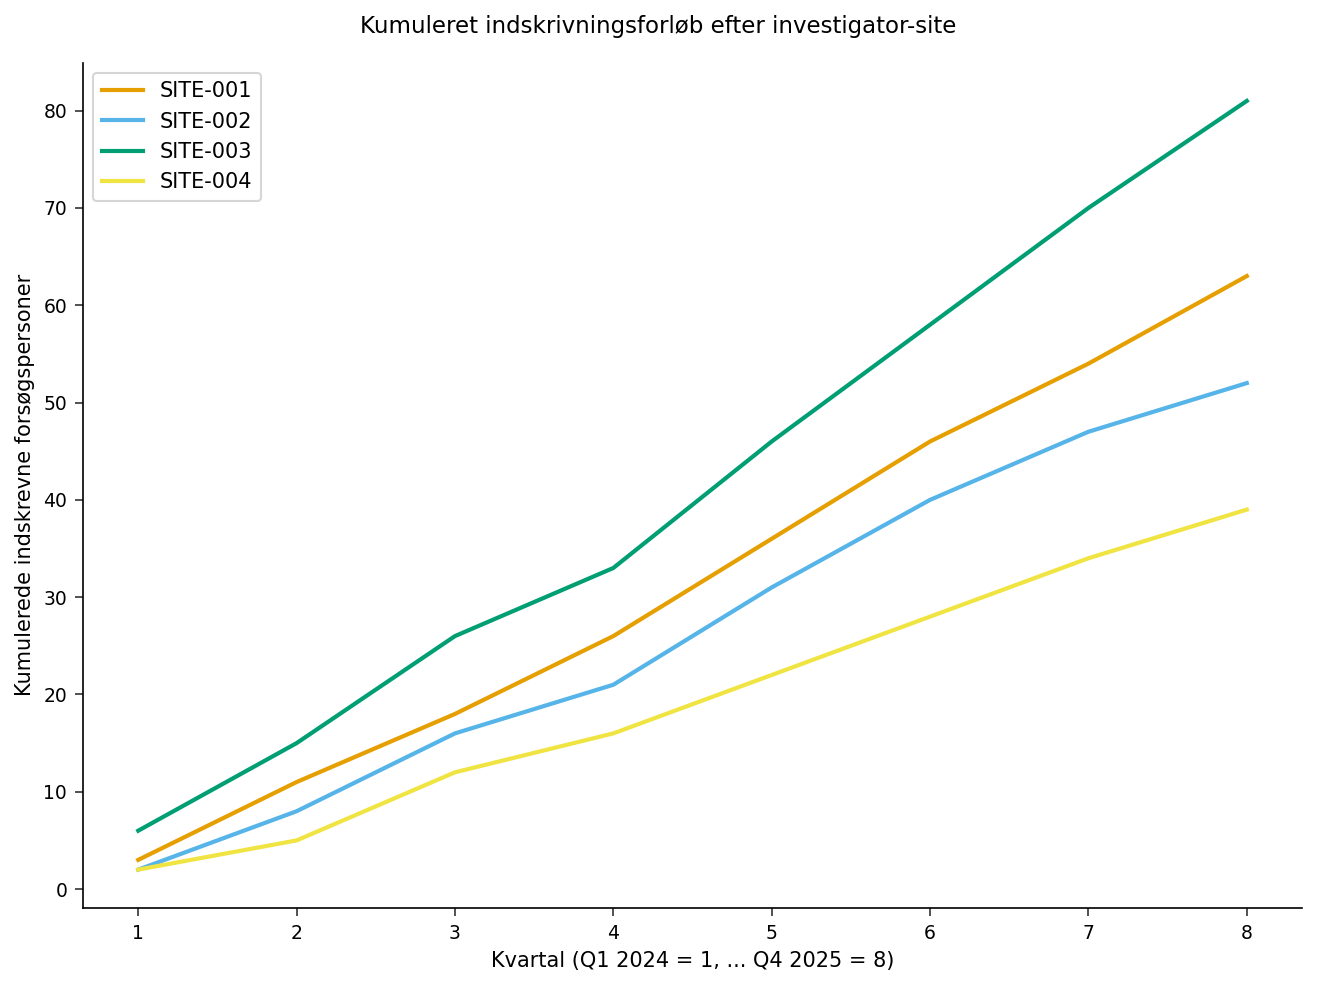

In [4]:
/* --------------------------------------------------------
   Kvartalsvis kumuleret indskrivningsforløb pr. site.
   Plottet mod et kvartalsindeks (1..8) for en ren akse.
   -------------------------------------------------------- */
data work.traj;
    SÆT work.enrollment_qtr;
    EFTER site_id;
    BEHOLD_VÆRDI quarter_index 0;
    HVIS first.site_id SÅ quarter_index = 0;
    quarter_index + 1;
KØR;

PROCEDURE SGPLOT data=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS MÆRKAT='Kvartal (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 TIL 8 EFTER 1);
    YAXIS MÆRKAT='Kumulerede indskrevne forsøgspersoner';
    TITEL 'Kumuleret indskrivningsforløb efter investigator-site';
KØR;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND kræver, at ID-variablen er sorteret inden for
   hver BY-gruppe, så sorter efter site og kvartal før konvertering.
   -------------------------------------------------------- */
PROCEDURE SORTER data=work.enrollment_qtr;
    EFTER site_id quarter_date;
KØR;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Konverter kvartalsvis indskrivning til månedlige estimater.

   FROM=QTR / TO=MONTH i PROC-sætningen sætter input- og
   outputfrekvensen; PROC EXPAND interpolerer hver BY-gruppe
   (site) uafhængigt langs ID-datoen.

   enrolled_count      -> METHOD=JOIN   (stykkevis lineær; flowværdien
                          forbliver ikke-negativ mellem ankerpunkter)
   cumulative_enrolled -> METHOD=SPLINE (glat monoton kurve)
   -------------------------------------------------------- */
PROCEDURE expand data=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr TIL=month;
    EFTER site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=SLUT     METHOD=SPLINE;
KØR;


                                     Kvartalsvis indskrivningsbaseline efter region                                     




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                     Kvartalsvis indskrivningsbaseline efter region                                     




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


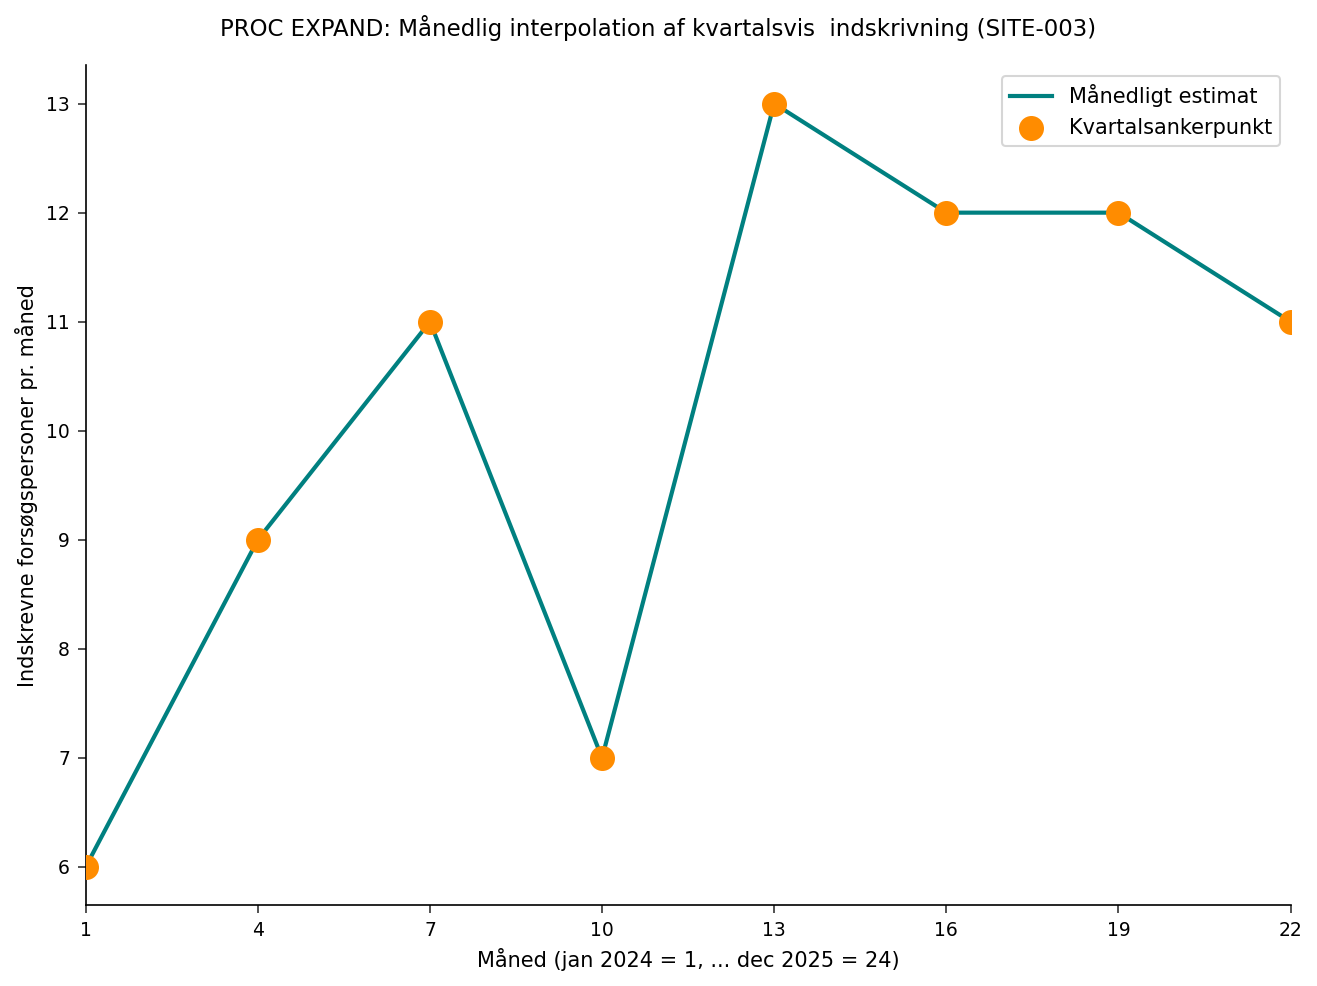

In [7]:
/* --------------------------------------------------------
   ID-variablen indeholder nu månedlige datoer. Omformater den og
   tilføj et månedsindeks (1..24) inden for hvert site til plotning.
   -------------------------------------------------------- */
data work.enrollment_monthly;
    SÆT work.enrollment_monthly;
    EFTER site_id;
    format month_date monyy7.;
    month_date = quarter_date;
    BEHOLD_VÆRDI month_index 0;
    HVIS first.site_id SÅ month_index = 0;
    month_index + 1;
    /* markér kvartalsankermånederne (1, 4, 7, ...) */
    HVIS mod(month_index - 1, 3) = 0 SÅ anchor = enrolled_count;
    ELLERS anchor = .;
KØR;

/* Vis konverteringen for et site: interpoleret månedlig linje,
   der passerer gennem de oprindelige kvartalsvise ankerpunkter. */
PROCEDURE SGPLOT data=work.enrollment_monthly;
    HVOR site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Månedligt estimat';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Kvartalsankerpunkt';
    XAXIS MÆRKAT='Måned (jan 2024 = 1, ... dec 2025 = 24)'
        integer VALUES=(1 TIL 24 EFTER 3);
    YAXIS MÆRKAT='Indskrevne forsøgspersoner pr. måned';
    TITEL 'PROC EXPAND: Månedlig interpolation af kvartalsvis '
        'indskrivning (SITE-003)';
KØR;


In [8]:
/* --------------------------------------------------------
   Kobl de månedlige estimater til site-metadata, og opsummer
   derefter månedlig indskrivning efter region.
   -------------------------------------------------------- */
PROCEDURE SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    VÆLG e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER EFTER s.region, e.site_id, e.month_date;
QUIT;

PROCEDURE GENNEMSNIT data=work.enrollment_monthly_region n sum mean;
    KLASSE region;
    VARIABEL monthly_estimate cumulative_estimate;
    MÆRKAT region='Region' monthly_estimate='Månedligt estimat'
          cumulative_estimate='Kumuleret estimat';
    UDDATA out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
KØR;

PROCEDURE UDSKRIV data=work.region_monthly_summary noobs;
    MÆRKAT region='Region' total_monthly_enrolled='Månedligt indskrevne i alt'
          avg_monthly_rate='Gnsn. månedlig rate';
    TITEL 'Månedlige estimater efter region';
KØR;


                                     Kvartalsvis indskrivningsbaseline efter region                                     

                                     Kvartalsvis indskrivningsbaseline efter region                                     

                                                  The MEANS Procedure

                                Analysis Variable : monthly_estimate Månedligt estimat

        Region               N Obs            Sum           Mean
        --------------------------------------------------------
        EUROPA                  44    336.0000000      7.6363636
        NORDAMERIKA             44    326.0000000      7.4090909
        --------------------------------------------------------

                               Analysis Variable : cumulative_estimate Kumuleret estimat

        Region               N Obs            Sum           Mean
        --------------------------------------------------------
        EUROPA                  48   1367.0000000  


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Fortolkning

PROC EXPAND konverterede de **32 kvartalsvise poster** (4 sites x 8 kvartaler) til **96 månedlige poster** ved hjælp af frekvenskonvertering langs hvert sites dato. Den interpolerede månedlige serie passerer nøjagtigt gennem de oprindelige kvartalsvise ankerværdier, som SITE-003-plottet viser: de orange punkter er de otte rapporterede kvartalstal, og den teal-farvede linje er det disaggregerede månedlige estimat, der forbinder dem.

På månedlig basis følger de to regioner hinanden tæt. Europa indskriver i gennemsnit **7.64** forsøgspersoner pr. site-måned og Nordamerika **7.41**, med regionale månedlige totaler på **336** og **326** forsøgspersoner over den interpolerede horisont. Fordi `METHOD=JOIN` ikke ekstrapolerer forbi det sidste kvartalsvise anker, bærer de sidste delkvartalsmåneder intet estimat og udelades fra de månedlige gennemsnit, hvilket er det konservative valg for fremadrettet planlægning.

Disse månedlige projektioner lader klinisk drift bevæge sig fra en kvartalsvis til en månedlig planlægningskadence -- dimensionering af lægemiddelforsyningsleverancer, planlægning af monitoreringsbesøg og rapportering af indskrivning til Data Safety Monitoring Board -- uden at genfremsætte nogen af de kvartalstal, studiet allerede har låst.


---

In [9]:
/* --------------------------------------------------------
   Eksporter månedlige indskrivningsprognoser til nedstrøms
   planlægningsværktøjer.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
KØR;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>